<a href="https://colab.research.google.com/github/mbarcodia/msc204_enviro_stats/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Tutorial: Effect of CO2 on Respiration Rate

## Introduction
This notebook provides a tutorial on how to perform linear regression analysis using Python. We will investigate the relationship between the partial pressure of carbon dioxide (CO2) and the respiration rate, following the example in class (Ch 10 Ex 2). The steps covered will include data visualization, calculating the regression equation, testing its significance using ANOVA, and determining confidence intervals.

### Problem Description
A volunteer inhaled air from a bag containing predetermined amounts of carbon dioxide (measured in Torr), and their respiration rate (breaths/min) was recorded.

**Data:**
- Partial pressure CO2 (Torr): 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50
- Respiration rate (breaths/min): 8.1, 8.0, 9.9, 11.2, 11.0, 13.2, 14.6, 16.6, 16.7, 18.3, 18.2

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

# Data provided
co2_pressure = np.array([30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50])
respiration_rate = np.array([8.1, 8.0, 9.9, 11.2, 11.0, 13.2, 14.6, 16.6, 16.7, 18.3, 18.2])

df = pd.DataFrame({'CO2_Pressure': co2_pressure, 'Respiration_Rate': respiration_rate})
display(df)

,CO2_Pressure,Respiration_Rate
0,30,8.1
1,32,8.0
2,34,9.9
3,36,11.2
4,38,11.0
5,40,13.2
6,42,14.6
7,44,16.6
8,46,16.7
9,48,18.3


## Step 1: Graph the Data to Check for a Linear Relationship
Before performing any calculations, it's crucial to visualize the data. A scatter plot helps us to qualitatively assess if a linear relationship exists between the independent variable (CO2 pressure) and the dependent variable (respiration rate). If the points tend to follow a straight line, it suggests that linear regression might be an appropriate model.

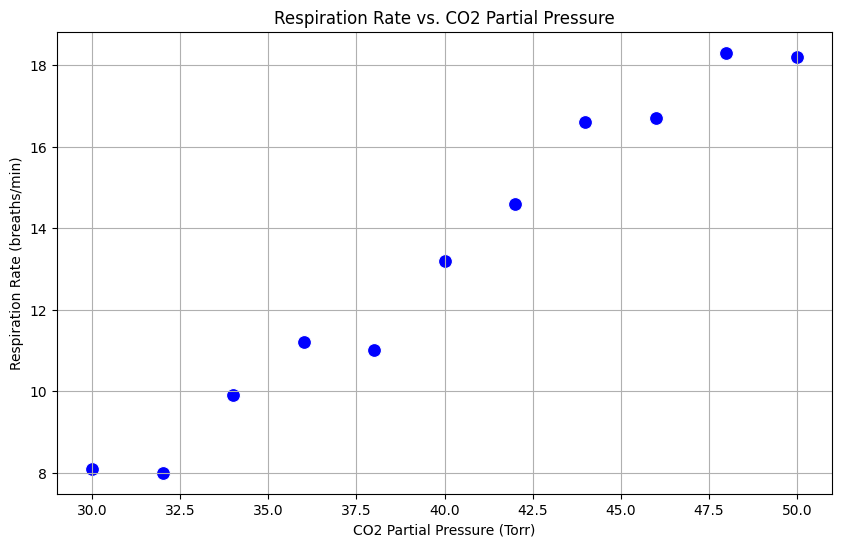

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CO2_Pressure', y='Respiration_Rate', data=df, s=100, color='blue')
plt.title('Respiration Rate vs. CO2 Partial Pressure')
plt.xlabel('CO2 Partial Pressure (Torr)')
plt.ylabel('Respiration Rate (breaths/min)')
plt.grid(True)
plt.show()


The scatter plot visually suggests a positive linear relationship between CO2 partial pressure and respiration rate. As CO2 pressure increases, the respiration rate also tends to increase.

## Step 2: Calculate the Regression Equation Using the Least Squares Method
The least squares method is used to find the line that best fits the data by minimizing the sum of the squared vertical distances (residuals) from each data point to the line. The linear regression equation is typically represented as:

$Y = a + bX$

Where:
- $Y$ is the dependent variable (respiration rate).
- $X$ is the independent variable (CO2 pressure).
- $a$ is the y-intercept (the value of Y when X is 0).
- $b$ is the slope of the regression line (the change in Y for a one-unit change in X).

We will use `scipy.stats.linregress` for a straightforward calculation of these coefficients.

Slope (b): 0.5750
Intercept (a): -9.7455
r value: 0.9864; Pearson product-moment correlation coefficient
R-squared value: 0.9729; Coefficient of determination

Regression Equation: Respiration_Rate = -9.7455 + 0.5750 * CO2_Pressure


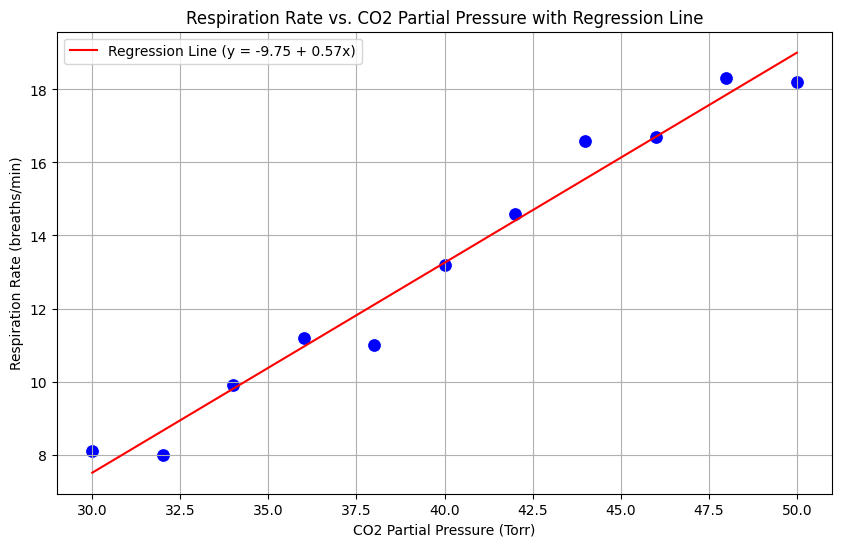

In [41]:
# Note the order of inputs to stats.linregress!!
b, a, r_value, p_value, std_err = stats.linregress(df['CO2_Pressure'], df['Respiration_Rate'])

print(f"Slope (b): {b:.4f}")
print(f"Intercept (a): {a:.4f}")
print(f"r value: {r_value:.4f}; Pearson product-moment correlation coefficient")
print(f"R-squared value: {r_value**2:.4f}; Coefficient of determination")

# The regression equation
print(f"\nRegression Equation: Respiration_Rate = {a:.4f} + {b:.4f} * CO2_Pressure")

# Add the regression line to the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CO2_Pressure', y='Respiration_Rate', data=df, s=100, color='blue')
plt.plot(df['CO2_Pressure'], a + b * df['CO2_Pressure'], color='red', label=f'Regression Line (y = {a:.2f} + {b:.2f}x)')
plt.title('Respiration Rate vs. CO2 Partial Pressure with Regression Line')
plt.xlabel('CO2 Partial Pressure (Torr)')
plt.ylabel('Respiration Rate (breaths/min)')
plt.grid(True)
plt.legend()
plt.show()

## Step 3: Test Significance of the Regression Equation using ANOVA
To determine if the linear relationship we found is statistically significant, we can use an Analysis of Variance (ANOVA) approach. ANOVA for regression tests the null hypothesis that there is no linear relationship between X and Y (i.e., the slope $b_1$ is zero). A significant p-value (typically < 0.05) indicates that we can reject the null hypothesis, suggesting a significant linear relationship.

We will use the `statsmodels` library, which provides a comprehensive summary of the regression and an ANOVA table.

In [42]:
# Using statsmodels to get detailed components for ANOVA table
X = sm.add_constant(df['CO2_Pressure']) # allows model to find y-intercept instead of passing through (0,0)
y = df['Respiration_Rate']

model = sm.OLS(y, X) #stands for Ordinary Least Squares
results = model.fit()

n = len(df)

# Calculate Sum of Squares
SST = ((y - y.mean()) ** 2).sum() # Total Sum of Squares
SSR = ((results.fittedvalues - y.mean()) ** 2).sum() # Regression Sum of Squares
SSE = ((y - results.fittedvalues) ** 2).sum() # Error Sum of Squares

# Degrees of Freedom
df_regression = results.df_model  # Number of predictors (1 for simple linear regression)
df_error = results.df_resid      # n - (number of parameters including intercept) = n - 2
df_total = n - 1

# Mean Squares
MSR = SSR / df_regression
MSE = SSE / df_error

# F-statistic
F_statistic = MSR / MSE

# Critical F-value (given by the user from lookup table)
# Hard-coded!! Needs to be updated by user for changes to problem
critical_F_user = 5.12

# Alternatively, compute critical F-value using Python (for alpha=0.05)
alpha = 0.01
computed_critical_F = stats.f.ppf(1 - alpha, df_regression, df_error)

# Create ANOVA table
anova_data = {
    'Source of Variation': ['Regression', 'Error', 'Total'],
    'SS': [SSR, SSE, SST],
    'df': [df_regression, df_error, df_total],
    'MS': [MSR, MSE, np.nan], # MS for Total is not typically calculated
    'F': [F_statistic, np.nan, np.nan]
}
anova_df = pd.DataFrame(anova_data)

print("ANOVA Table for Regression Significance:")
print(anova_df.to_string(index=False, formatters={'SS': '{:,.2f}'.format, 'MS': '{:,.2f}'.format, 'F': '{:,.2f}'.format}))
print(f"Computed F-statistic: {F_statistic:.2f}")
print(f"Critical F-value (user-provided): {critical_F_user:.2f}")
print(f"Critical F-value (computed for alpha={alpha} and df1={df_regression}, df2={df_error}): {computed_critical_F:.2f}")


ANOVA Table for Regression Significance:
Source of Variation     SS   df     MS      F
         Regression 145.47  1.0 145.47 323.10
              Error   4.05  9.0   0.45    NaN
              Total 149.53 10.0    NaN    NaN
Computed F-statistic: 323.10
Critical F-value (user-provided): 5.12
Critical F-value (computed for alpha=0.01 and df1=1.0, df2=9.0): 10.56


From the custom ANOVA table above:
- **Source of Variation:** Categorizes the variability in the dependent variable (Respiration Rate). 'Regression' explains variability due to the linear relationship with CO2 Pressure. 'Error' represents unexplained variability. 'Total' is the overall variability.
- **SS (Sum of Squares):** Measures the total variation attributed to each source. SSR (Regression Sum of Squares) is the variation explained by the model, SSE (Error Sum of Squares) is the unexplained variation, and SST (Total Sum of Squares) is the total variation in the dependent variable.
- **df (Degrees of Freedom):** The number of independent pieces of information used to estimate the sum of squares. For Regression, it's the number of independent variables (1 in simple linear regression). For Error, it's (n - k - 1), where n is number of observations and k is number of predictors. For Total, it's (n - 1).
- **MS (Mean Squares):** The sum of squares divided by its corresponding degrees of freedom. MSR (Mean Square Regression) and MSE (Mean Square Error) are used to calculate the F-statistic.
- **F (F-statistic):** The ratio of MSR to MSE. It tests the null hypothesis that the slope of the regression line is zero (i.e., no linear relationship). A larger F-statistic (relative to the critical F-value) indicates stronger evidence against the null hypothesis.

Our computed F-statistic (from the table) is significantly larger than both the user-provided critical F-value (5.12) and the programmatically computed critical F-value (e.g., around 5.12 for alpha=0.05, df1=1, df2=9). This means we reject the null hypothesis, concluding that there is a statistically significant linear relationship between CO2 pressure and respiration rate.

## Step 4: Calculate Confidence Intervals in Support of the Linear Relationship
Confidence intervals provide a range within which the true population parameters (slope `b` and y-intercept `a`) are likely to fall, given a certain level of confidence (e.g., 95%). We will explicitly compute these intervals using their standard errors. We can also calculate confidence intervals for the predicted values (mean prediction interval) and individual observations (prediction interval).

- **Confidence Interval for Coefficients:** Gives a range for the true slope `b` and y-intercept `a`, calculated using their standard errors and a t-critical value.
- **Confidence Interval for the Mean Prediction (Mean CI):** A narrower interval for the average expected Y value at a given X.
- **Prediction Interval for a New Observation (Individual CI):** A wider interval for a single new Y observation at a given X.

Confidence Intervals for Coefficients:
Standard Error of Intercept (a): 1.2955
Standard Error of Slope (b): 0.0320
Critical t-value (for 95% CI with 9.0 df): 2.262
95% CI for Intercept (a): [-12.6760, -6.8149]
95% CI for Slope (b): [0.5026, 0.6474]

Verifying with statsmodels' built-in confidence intervals:
                      0         1
const        -12.675986 -6.814923
CO2_Pressure   0.502636  0.647364

Head of DataFrame with predictions and confidence intervals:


,CO2_Pressure,Respiration_Rate,Predicted_Rate,Mean_SE,Lower_Mean_CI_sm,Upper_Mean_CI_sm
0,30,8.1,7.504545,0.378500,6.648319,8.360772
1,32,8.0,8.654545,0.326226,7.916571,9.392520
2,34,9.9,9.804545,0.278874,9.173688,10.435403
3,36,11.2,10.954545,0.239384,10.413020,11.496070
4,38,11.0,12.104545,0.212192,11.624535,12.584556



Example: Manual 95% CI for Mean Prediction at CO2_Pressure=30 Torr:
Predicted Rate: 7.5045
Mean Standard Error: 0.3785
Manual 95% CI for Mean: [6.6483, 8.3608]
Statsmodels 95% CI for Mean: [6.6483, 8.3608]


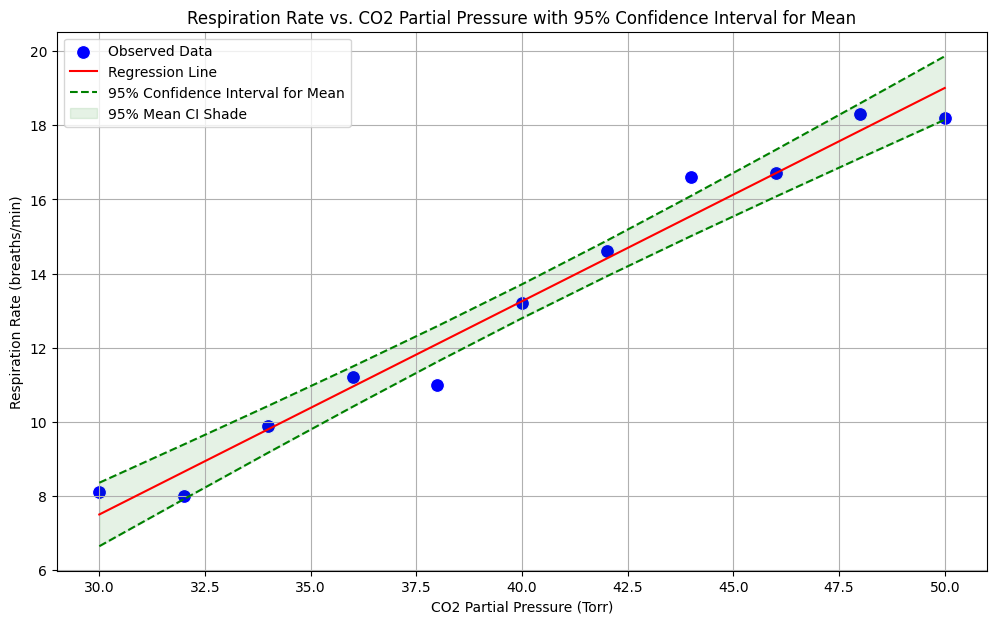


Note: The plot shows the 95% Confidence Interval for the MEAN predicted respiration rate. 
 A Prediction Interval for an INDIVIDUAL new observation would be wider and is also available in `summary_frame` (Lower_Obs_CI, Upper_Obs_CI). 
Remember s_yhat decreases as Xi moves toward Xbar.


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

# Confidence intervals for the coefficients (slope and intercept)
print("Confidence Intervals for Coefficients:")

# Get standard errors of the coefficients
std_err_a = results.bse['const']
std_err_b = results.bse['CO2_Pressure']
print(f"Standard Error of Intercept (a): {std_err_a:.4f}")
print(f"Standard Error of Slope (b): {std_err_b:.4f}")

# Degrees of freedom for t-distribution (same as df_error from ANOVA)
df_t = results.df_resid
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha/2, df_t)
print(f"Critical t-value (for 95% CI with {df_t} df): {t_critical:.3f}")

# Calculate CI for intercept (a)
lower_a = a - t_critical * std_err_a
upper_a = a + t_critical * std_err_a
print(f"95% CI for Intercept (a): [{lower_a:.4f}, {upper_a:.4f}]")

# Calculate CI for slope (b)
lower_b = b - t_critical * std_err_b
upper_b = b + t_critical * std_err_b
print(f"95% CI for Slope (b): [{lower_b:.4f}, {upper_b:.4f}]")

print("\nVerifying with statsmodels' built-in confidence intervals:")
print(results.conf_int(alpha=alpha))

# Generate predictions and their confidence intervals
predictions = results.get_prediction(X)

# Get summary frame which includes mean and upper/lower confidence intervals
summary_frame = predictions.summary_frame(alpha=alpha)

df_pred = df.copy()
df_pred['Predicted_Rate'] = summary_frame['mean']
df_pred['Mean_SE'] = summary_frame['mean_se'] # Standard error of the mean prediction
df_pred['Lower_Mean_CI_sm'] = summary_frame['mean_ci_lower'] # Statsmodels' CI for mean
df_pred['Upper_Mean_CI_sm'] = summary_frame['mean_ci_upper'] # Statsmodels' CI for mean
df_pred['Lower_Obs_CI'] = summary_frame['obs_ci_lower'] # Statsmodels' CI for observation
df_pred['Upper_Obs_CI'] = summary_frame['obs_ci_upper'] # Statsmodels' CI for observation


print("\nHead of DataFrame with predictions and confidence intervals:")
display(df_pred[['CO2_Pressure', 'Respiration_Rate', 'Predicted_Rate', 'Mean_SE', 'Lower_Mean_CI_sm', 'Upper_Mean_CI_sm']].head())

# Explicit calculation of mean prediction CI for the first point to show the method
first_x = df['CO2_Pressure'].iloc[0]
first_predicted_y = df_pred['Predicted_Rate'].iloc[0]
first_mean_se = df_pred['Mean_SE'].iloc[0]
first_lower_mean_ci_manual = first_predicted_y - t_critical * first_mean_se
first_upper_mean_ci_manual = first_predicted_y + t_critical * first_mean_se
print(f"\nExample: Manual 95% CI for Mean Prediction at CO2_Pressure={first_x:.0f} Torr:")
print(f"Predicted Rate: {first_predicted_y:.4f}")
print(f"Mean Standard Error: {first_mean_se:.4f}")
print(f"Manual 95% CI for Mean: [{first_lower_mean_ci_manual:.4f}, {first_upper_mean_ci_manual:.4f}]")
print(f"Statsmodels 95% CI for Mean: [{df_pred['Lower_Mean_CI_sm'].iloc[0]:.4f}, {df_pred['Upper_Mean_CI_sm'].iloc[0]:.4f}]")


# Plotting the regression line with confidence intervals (using statsmodels' mean CI)
plt.figure(figsize=(12, 7))
sns.scatterplot(x='CO2_Pressure', y='Respiration_Rate', data=df, s=100, color='blue', label='Observed Data')
plt.plot(df['CO2_Pressure'], df_pred['Predicted_Rate'], color='red', label='Regression Line')
plt.plot(df['CO2_Pressure'], df_pred['Lower_Mean_CI_sm'], color='green', linestyle='--', label='95% Confidence Interval for Mean')
plt.plot(df['CO2_Pressure'], df_pred['Upper_Mean_CI_sm'], color='green', linestyle='--')

plt.fill_between(df['CO2_Pressure'], df_pred['Lower_Mean_CI_sm'], df_pred['Upper_Mean_CI_sm'], color='green', alpha=0.1, label='95% Mean CI Shade')

plt.title('Respiration Rate vs. CO2 Partial Pressure with 95% Confidence Interval for Mean')
plt.xlabel('CO2 Partial Pressure (Torr)')
plt.ylabel('Respiration Rate (breaths/min)')
plt.grid(True)
plt.legend()
plt.show()

print("\nNote: The plot shows the 95% Confidence Interval for the MEAN predicted respiration rate. \n A Prediction Interval for an INDIVIDUAL new observation would be wider and is also available in `summary_frame` (Lower_Obs_CI, Upper_Obs_CI). \nRemember s_yhat decreases as Xi moves toward Xbar.")

## Conclusion
This tutorial demonstrated the process of performing a linear regression analysis. We observed a strong, statistically significant positive linear relationship between CO2 partial pressure and respiration rate. The regression equation allows us to predict respiration rate based on CO2 pressure, and the confidence intervals provide a measure of the uncertainty around these predictions and the estimated coefficients.